In [98]:
import pandas as pd #FOR DATA MANIPULATION And frame 
import numpy as np #FOR NUMERICAL CALCULATIONS
import matplotlib.pyplot as plt #FOR VISUALIZATION
import seaborn as sns #FOR VISUALIZATION And Graphs
import kagglehub #FOR KAGGLE DATASET MANAGEMENT
import os #FOR handling file paths and directories

In [99]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn kagglehub

zsh:1: no such file or directory: /Users/harshkataria/Desktop/Portfolio/Netflix


In [100]:
import sys
# We add double quotes around {sys.executable} to handle the space in the folder name
!"{sys.executable}" -m pip install pandas numpy matplotlib seaborn kagglehub

In [101]:
import pandas as pd
print(f"Pandas version: {pd.__version__}")
print("Success! You are ready to go.")

Pandas version: 3.0.1
Success! You are ready to go.


In [102]:
import pandas as pd #FOR DATA MANIPULATION And frame 
import numpy as np #FOR NUMERICAL CALCULATIONS
import matplotlib.pyplot as plt #FOR VISUALIZATION
import seaborn as sns #FOR VISUALIZATION And Graphs
import kagglehub #FOR KAGGLE DATASET MANAGEMENT
import os #FOR handling file paths and directories

In [103]:
path = kagglehub.dataset_download("swatikhedekar/exploratory-data-analysis-on-netflix-data")
all_files = os.listdir(path)
# Filter for only CSV files
csv_files = [f for f in all_files if f.endswith('.csv')]
if csv_files:
    # Use the first actual CSV found
    csv_path = os.path.join(path, csv_files[0])
    netflix_data = pd.read_csv(csv_path, encoding='latin1')
    print(netflix_data.shape)
    print(netflix_data.head())
    
else:
    print("No CSV file found in the directory!")

(8807, 12)
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2

In [104]:
print(netflix_data.isnull().sum())


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [105]:

# 1. Fix categorical columns with missing values
netflix_data['director'].fillna('Unknown', inplace=True)
netflix_data['cast'].fillna('Unknown', inplace=True)
netflix_data['country'].fillna('Unknown', inplace=True)

# 2. Fix date_added column
netflix_data['date_added'] = pd.to_datetime(netflix_data['date_added'], errors='coerce')
netflix_data['date_added'].fillna(pd.Timestamp('2023-01-01'), inplace=True)

# 3. Fix rating column
netflix_data['rating'].fillna(netflix_data['rating'].mode()[0], inplace=True)

# 4. Fix duration column
netflix_data['duration'].fillna('Unknown', inplace=True)

# 5. Verify that missing values are gone
print(netflix_data.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        98
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


/var/folders/4v/0ctfbz0x31gdn81lsr3x2xzm0000gn/T/ipykernel_86344/1987162111.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  netflix_data['director'].fillna('Unknown', inplace=True)
/var/folders/4v/0ctfbz0x31gdn81lsr3x2xzm0000gn/T/ipykernel_86344/1987162111.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFram

In [106]:
netflix_data['director'] = netflix_data['director'].fillna('Unknown')
netflix_data['cast'] = netflix_data['cast'].fillna('Unknown')
netflix_data['country'] = netflix_data['country'].fillna('Unknown')

# 2. Fix date_added column
netflix_data['date_added'] = pd.to_datetime(netflix_data['date_added'], errors='coerce')
netflix_data['date_added'] = netflix_data['date_added'].fillna(pd.Timestamp('2023-01-01'))

# 3. Fix rating column
netflix_data['rating'] = netflix_data['rating'].fillna(netflix_data['rating'].mode()[0])

# 4. Fix duration column
netflix_data['duration'] = netflix_data['duration'].fillna('Unknown')

# 5. Verify missing values
print(netflix_data.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [107]:
print("\nData types of each column:")
print(netflix_data.dtypes)


Data types of each column:
show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object


In [108]:
netflix_data['type'] = netflix_data['type'].astype('category')
netflix_data['rating'] = netflix_data['rating'].astype('category')
netflix_data['date_added'] = pd.to_datetime(netflix_data['date_added'], errors='coerce')
print("\nData types after conversion:")
print(netflix_data.dtypes)



Data types after conversion:
show_id                    str
type                  category
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                category
duration                   str
listed_in                  str
description                str
dtype: object


In [109]:
# 3. Check sample of date column for invalid or inconsistent entries
print("\nSample of 'date_added' column:")
print(netflix_data['date_added'].head(20))

# 4. Optional: see unique types in categorical columns
categorical_cols = ['type', 'rating']
for col in categorical_cols:
    print(f"\nUnique values in {col}: {netflix_data[col].unique()}")



Sample of 'date_added' column:
0    2021-09-25
1    2021-09-24
2    2021-09-24
3    2021-09-24
4    2021-09-24
5    2021-09-24
6    2021-09-24
7    2021-09-24
8    2021-09-24
9    2021-09-24
10   2021-09-24
11   2021-09-23
12   2021-09-23
13   2021-09-22
14   2021-09-22
15   2021-09-22
16   2021-09-22
17   2021-09-22
18   2021-09-22
19   2021-09-22
Name: date_added, dtype: datetime64[us]

Unique values in type: ['Movie', 'TV Show']
Categories (2, str): ['Movie', 'TV Show']

Unique values in rating: ['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', ..., '84 min', '66 min', 'NR', 'TV-Y7-FV', 'UR']
Length: 17
Categories (17, str): ['66 min', '74 min', '84 min', 'G', ..., 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'UR']


In [110]:
# 3. Extract features from date_added
netflix_data['year_added'] = netflix_data['date_added'].dt.year
netflix_data['month_added'] = netflix_data['date_added'].dt.month
netflix_data['weekday_added'] = netflix_data['date_added'].dt.day_name()

print("\nSample with new date features:")
print(netflix_data[['date_added', 'year_added', 'month_added', 'weekday_added']].head())



Sample with new date features:
  date_added  year_added  month_added weekday_added
0 2021-09-25        2021            9      Saturday
1 2021-09-24        2021            9        Friday
2 2021-09-24        2021            9        Friday
3 2021-09-24        2021            9        Friday
4 2021-09-24        2021            9        Friday


In [111]:
# check for duplicates
duplicate_rows = netflix_data.duplicated()
print("Number of duplicate rows:", duplicate_rows.sum()) 


Number of duplicate rows: 0


In [112]:
# Check numeric ranges
netflix_data.loc[~netflix_data['release_year'].between(1900, 2026), 'release_year'] = 2023


In [113]:
print(netflix_data.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added  release_year rating   duration  \
0 2021-09-25          2020  PG-13     90 min   
1 2021-09-24          2021  TV-MA  2 Seasons   
2 2021-09-24          2021  TV-MA   1 Season   
3 2021-0

In [114]:
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


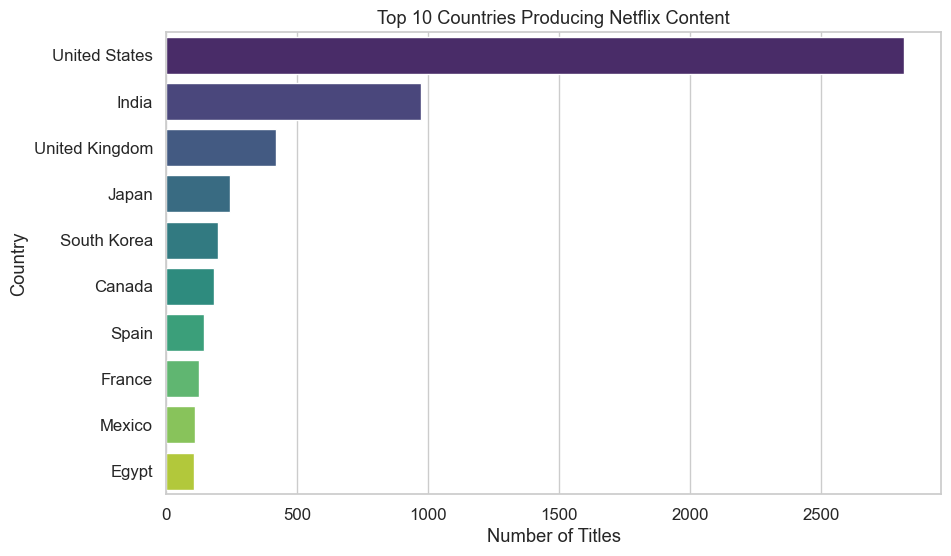

In [115]:
#  Which country produces the most content?
top_countries = top_countries = netflix_data[netflix_data['country'] != 'Unknown']['country'].value_counts().head(10)
print(top_countries.head(10))
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_countries.values, 
    y=top_countries.index, 
    hue=top_countries.index,   # assign y variable to hue
    dodge=False,               # prevents splitting bars
    palette="viridis"
)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.legend([],[], frameon=False)  # remove the extra legend
plt.show()

In [116]:
netflix_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8807 non-null   str           
 1   type           8807 non-null   category      
 2   title          8807 non-null   str           
 3   director       8807 non-null   str           
 4   cast           8807 non-null   str           
 5   country        8807 non-null   str           
 6   date_added     8807 non-null   datetime64[us]
 7   release_year   8807 non-null   int64         
 8   rating         8807 non-null   category      
 9   duration       8807 non-null   str           
 10  listed_in      8807 non-null   str           
 11  description    8807 non-null   str           
 12  year_added     8807 non-null   int32         
 13  month_added    8807 non-null   int32         
 14  weekday_added  8807 non-null   str           
dtypes: category(2), datetime64[us](1

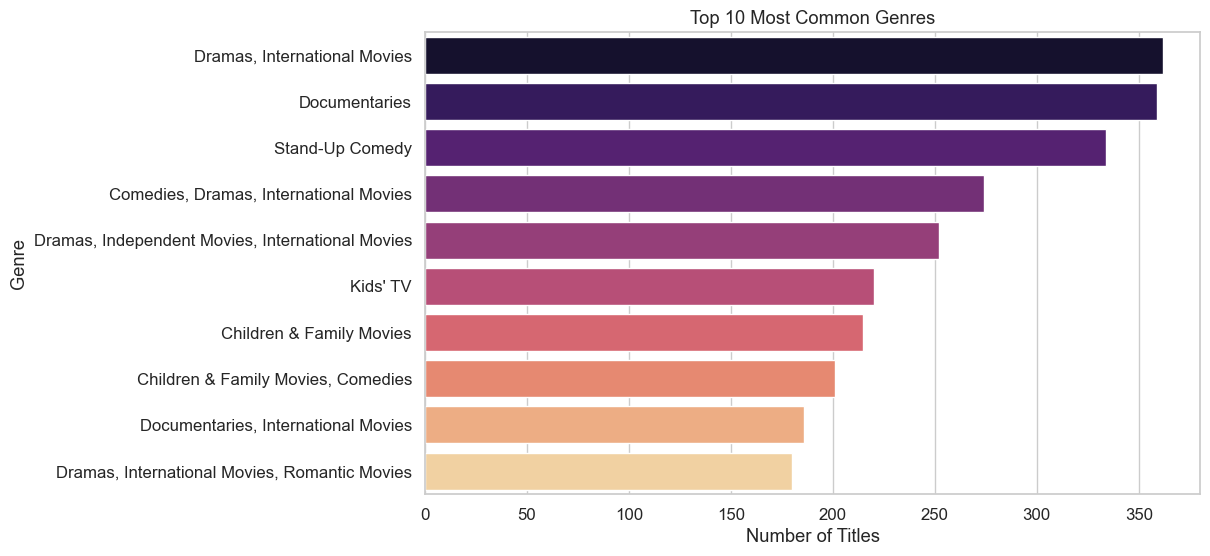

In [117]:
# Explode multi-genre entries
genres = netflix_data['listed_in'].explode()

# Count top 10 genres
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,  # satisfies Seaborn palette requirement
    dodge=False,
    palette="magma"
)
plt.title("Top 10 Most Common Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.legend([],[], frameon=False)
plt.show()

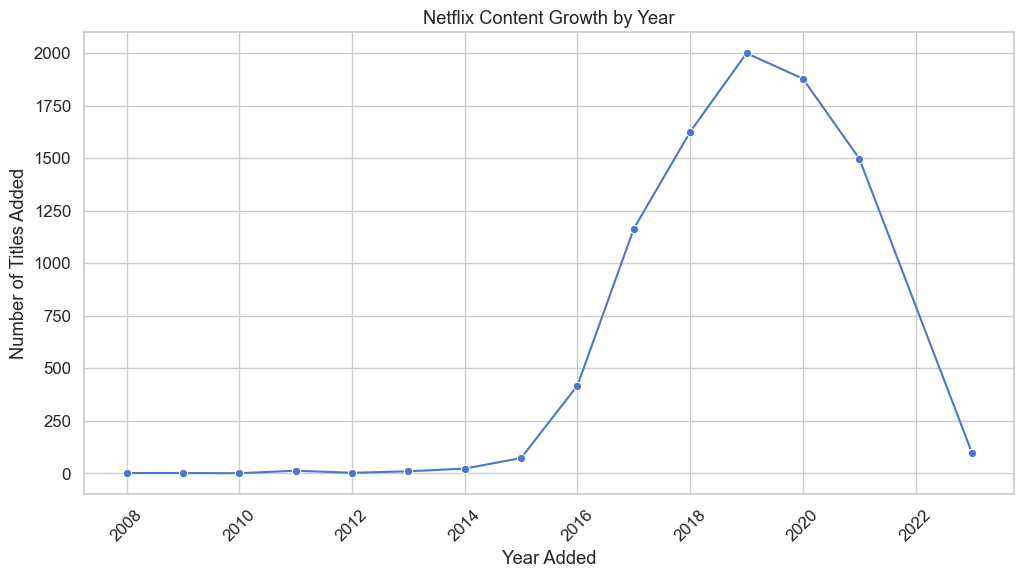

In [118]:
# Count number of titles added each year
year_counts = netflix_data['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o")
plt.title("Netflix Content Growth by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.xticks(rotation=45)
plt.show()

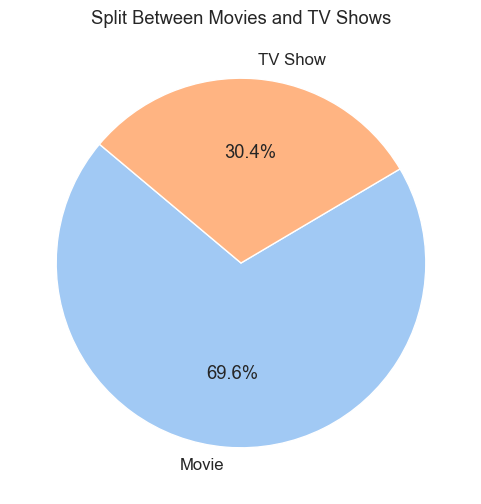

In [119]:
type_counts = netflix_data['type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel")
)
plt.title("Split Between Movies and TV Shows")
plt.show()

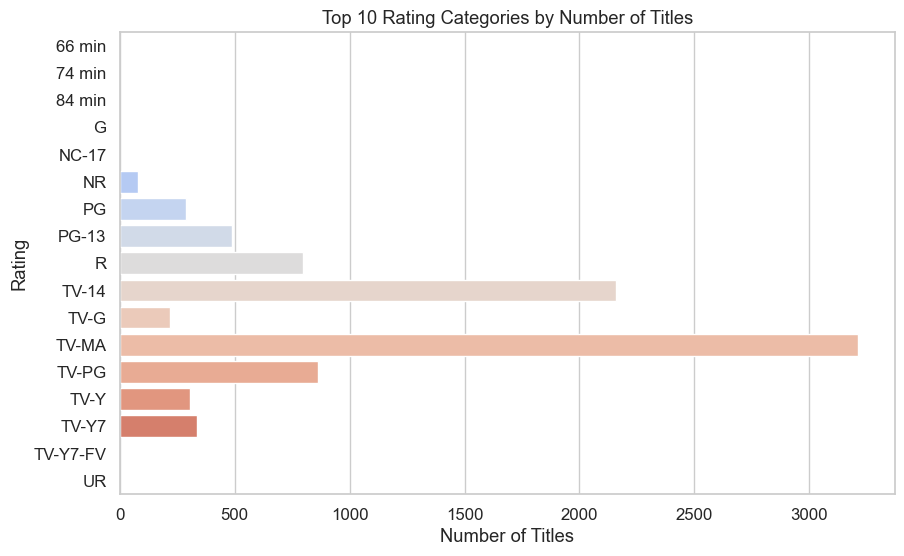

In [120]:
# Top 10 rating categories
top_ratings = netflix_data[~netflix_data['rating'].isin(['Unknown'])]['rating'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_ratings.values,
    y=top_ratings.index,
    hue=top_ratings.index,
    dodge=False,
    palette="coolwarm"
)
plt.title("Top 10 Rating Categories by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.legend([],[], frameon=False)
plt.show()